In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as srs
from sklearn.preprocessing  import OneHotEncoder, LabelEncoder
import numpy as np

## Exercice1: Exploration initiale et profilage des données

Importation du jeu de données

In [2]:
df = pd.read_csv("typhoide_health_data.csv")

Informations sur le jeu de données

In [3]:
type(df)
df.shape
df.info()
df.head()
df.duplicated().sum()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   300 non-null    int64  
 1   Sexe                  300 non-null    object 
 2   Region                300 non-null    object 
 3   Temperature           300 non-null    float64
 4   Duree_fievre          300 non-null    int64  
 5   Test_typhoide         300 non-null    object 
 6   Source_eau            300 non-null    object 
 7   Acces_assainissement  300 non-null    object 
 8   Antibiotherapie       300 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 21.2+ KB


Age                     0
Sexe                    0
Region                  0
Temperature             0
Duree_fievre            0
Test_typhoide           0
Source_eau              0
Acces_assainissement    0
Antibiotherapie         0
dtype: int64

In [4]:
df.describe()

,Age,Temperature,Duree_fievre
count,300.000000,300.000000,300.000000
mean,39.993333,38.543667,7.360000
std,22.276462,1.707311,3.994612
min,1.000000,35.500000,1.000000
25%,20.000000,37.100000,4.000000
50%,39.500000,38.600000,7.000000
75%,58.250000,40.000000,11.000000
max,80.000000,41.500000,14.000000


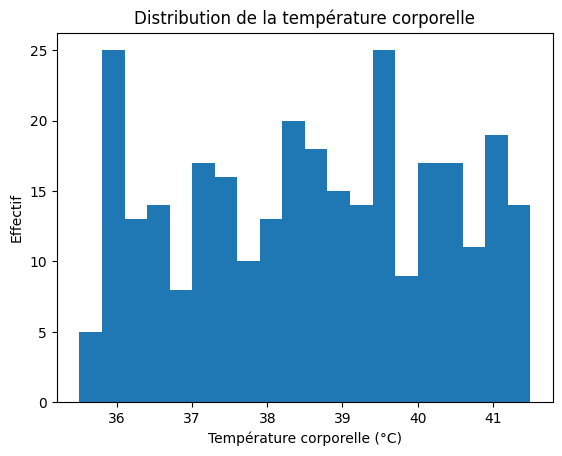

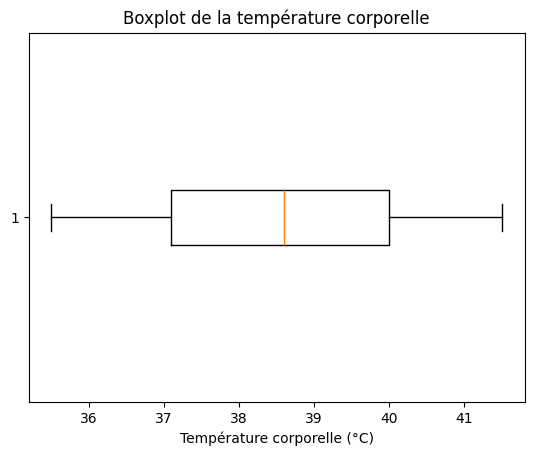

In [5]:
#Visualisation de la distribution de la température corporelle
plt.hist(df['Temperature'], bins=20)
plt.xlabel('Température corporelle (°C)')
plt.ylabel('Effectif')
plt.title('Distribution de la température corporelle')
plt.show()

plt.boxplot(df['Temperature'], vert=False)
plt.xlabel('Température corporelle (°C)')
plt.title('Boxplot de la température corporelle')
plt.show()

In [11]:
#Détection des valeurs abérrantes à partir de la méthode des écarts inter quartiles (IQR)
Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df[(df['Temperature'] < borne_inf) & (df['Temperature'] > borne_sup)]
outliers

outliers.shape[0]

0

In [16]:
# Nombre de valeus uniques
df['Sexe'].value_counts()

Sexe
F    156
M    144
Name: count, dtype: int64

In [17]:
df['Test_typhoide'].value_counts()

Test_typhoide
Positif    185
Negatif    115
Name: count, dtype: int64

In [18]:
df['Source_eau'].value_counts()

Source_eau
Riviere    104
Puits       99
Potable     97
Name: count, dtype: int64

### Exercice 1:
1.Nous constatons que notre jeu de données cotient 300 lignes indexées de 0 à 299 et 9 colonnes 
   Age et Durre_fievre de type entier,
   Temperature de type réel;
   Et Sexe, Region, Test_typhoide, Source_eau, acces_assainnissement et Antibiotherapie de type objet
2.Toutes les colonnes ont 300 valeurs non nulles c'est-a-dire qu'il y'a aucune donnée manquante dans ce jeu de données
 Iln y'a pas de doublons
3.Statistiques descriptives
   *Age
      Moyenne : 39.993333
      max : 80.000000
      min : 1.000000
   *Duree_fievre
      Moyenne : 7.360000
      max : 14.000000
      min : 1.000000
4.Distribution de la température corporelle
   Nous avons
      .Une distribution centrée autour de 37–38°C ce qui est normale
      .Une queue longue à droite → fièvres élevées
      .Plusieurs pics → sous-groupes de patients
   Valeurs aberrantes
      Interpretation
         < 35°C → hypothermie (rare)
         > 39,5°C → fièvre sévère
   Il y'a pas de valeurs abérantes
5.Nombre de valeurs uniques
   - Sexe: 2 valeurs uniques
   -Test_typhoide: 2 valeurs uniques
   -Source_eau: 3 valeurs uniques

## Exercice 2: Analyse descriptive et épidémiologique

In [19]:

df.groupby('Test_typhoide')['Temperature'].agg(['mean', 'min', 'max', 'std'])

,mean,min,max,std
Test_typhoide,,,,
Negatif,37.936522,35.5,41.5,1.733131
Positif,38.921081,35.5,41.5,1.581805


In [20]:
# Taux de positivité par région
taux_positivite = (
    df.groupby('Region')['Test_typhoide']
      .apply(lambda x: (x == 'Positif').mean() * 100)
)

taux_positivite

Region
Est      66.197183
Nord     56.944444
Ouest    65.263158
Sud      56.451613
Name: Test_typhoide, dtype: float64

In [22]:
# Test de positivité par accès à l'assainissement
taux_assainissement = (
    df.groupby('Acces_assainissement')['Test_typhoide']
      .apply(lambda x: (x == 'Positif').mean() * 100)
)

taux_assainissement

Acces_assainissement
Non    64.383562
Oui    59.090909
Name: Test_typhoide, dtype: float64

In [23]:
# Durée moyenne de la fièvre en fonction du résultat du test
df.groupby('Test_typhoide')['Duree_fievre'].mean()

Test_typhoide
Negatif    6.078261
Positif    8.156757
Name: Duree_fievre, dtype: float64

In [27]:
# Analyse croisée entre la source d'eau et le résultat du test
table_eau_test = pd.crosstab(df['Source_eau'], df['Test_typhoide'])
table_eau_test

taux_par_eau = pd.crosstab(
    df['Source_eau'],
    df['Test_typhoide'],
    normalize='index'
) * 100
taux_par_eau

Test_typhoide,Negatif,Positif
Source_eau,,
Potable,35.051546,64.948454
Puits,40.404040,59.595960
Riviere,39.423077,60.576923


### Exercice 2

1. Comparons le températures moyennes
        La température moyenne des patients testés positifs est supérieure à celle des patients testés négatifs, ce qui suggère une association entre la fièvre élevée et la présence de la typhoïde.
2. Calculons le taux de positivité par régions
    Nous avons:
        Est      66.197183
        Nord     56.944444
        Ouest    65.263158
        Sud      56.451613
3. Évaluons si les personnes sans accès à l’assainissement sont plus souvent testées positives
    Nous pouvons constater que les personnes sans accès à l’assainissement sont plus souvent testées positives car la moyenne de l’assainissement négatif est superieur àcelui de l’assainissement positif
4. Comparons la durée moyenne de la fièvre entre les patients positifs et négatifs
        Negatif    6.078261
        Positif    8.156757
        La durée moyenne de la fièvre chez les patients positits est supérieure à la durée moyenne de la fièvre chez les patients négatifs
5.	Analysons l’association entre la source d’eau et le résultat du test
        Les personnes utilisant des sources d’eau non traitées (puits, rivière) présentent des taux de positivité plus élevés que celles utilisant de l’eau du robinet ou de forage, suggérant une association entre la qualité de l’eau et la survenue de la typhoïde.


## Exercice 3 : Analyse de la qualité des données

In [39]:
df_impossible = df[(df['Temperature'] < 35) | (df['Temperature'] > 42)]
df_impossible.shape[0]

0

In [40]:
df['Duree_fievre'].isna().sum()

np.int64(0)

In [41]:
df['Sexe'].value_counts()

Sexe
F    156
M    144
Name: count, dtype: int64

In [42]:
df['Test_typhoide'].value_counts()

Test_typhoide
Positif    185
Negatif    115
Name: count, dtype: int64

### Exercice 3:
1. les valeurs ded température physiologiquement impossibles sont les valeurs inférieures à 35 et supérieures à 38 car Chez l’être humain, la température corporelle normale se situe environ entre 36,5°C et 37,5°C.
Même en cas de maladie grave, les limites physiologiques restent restreintes.
2.	Comptons les valeurs manquantes dans la variable Durée_fièvre et discutons :
        Il y'a pas de valeurs manquantes
3. 3.	Vérifions les incohérences dans :
	Sexe (M, m, Masculin…)
        Il y'a pas d'incohérences
	Test_typhoide (positif, Positif, POSITIF…)
        il y'a pas d'incohérences
4.	Proposons des règles de validation pour garantir la qualité future des données
        Règles pour les variables numériques

            Température:	35°C ≤ Température ≤ 42°C	Température physiologiquement plausible
            Durée_fievre:	0 ≤ Durée_fievre ≤ 30 (ou selon contexte clinique)	Évite les valeurs négatives ou irréalistes
            Age:   Age >= 0	Évite les erreurs de saisie (âge négatif ou improbable)

        Règles pour les variables catégorielles

            Sexe:	Modalités limitées : M / F pour	Évite les variations (Masculin, m, féminin, F)
            Test_typhoide:   Modalités limitées : Positif / Negatif pour	Évite les fautes de frappe et différences de casse
            Source_eau:   Liste prédéfinie de sources valides pour Évite les valeurs inconnues
            Acces_assainissement:	Oui / Non pour Évite les valeurs ambiguës
            Antibiotherapie:	Oui / Non pour Standardisation des réponses

        Règles pour les valeurs manquantes

            - Interdire les valeurs manquantes pour les variables critiques : Age, Sexe, Test_typhoide, Temperature
            - Si données manquantes : alerter et enregistrer dans un journal pour suivi
            - Prévoir imputation standardisée si certaines variables peuvent être manquantes (ex. durée de fièvre)

## Exercice 4 : Réflexion et rapport (Analyse critique)

### Exercice 4:
1. 	Résumons les principaux problèmes de qualité des données observés
        Au cour de notre travail, nous avons exploré plusieurs problèmes de qualité que l'on retrouve généralement dans des jeux de données tels que:  les valeurs manquantes, les températures physiologiquement impossibles, les incohérences dans les variables catégorielles, les formats non standard et les incohérences entre certaines variables. après toute cette exploration, nous n'avons trouvé aucun de ces problèmes dans notre jeu de données
2.	Proposer des stratégies de nettoyage adaptées à chaque problème identifié
           Puisque nous n'avons pas trouvé de problèmes, nous n'avons pas se solutions
3.	Mettons en évidence au moins trois facteurs de risque associés à la fièvre typhoïde à partir des données
           Nous avons:
              - La région: l'Est et l'Ouest sont les région les plus risquées
              - L'accès à l'assainissement: les personnes sans accès à l’assainissement sont plus souvent testées positives
              - La source d'eau: Les personnes utilisant des sources d’eau non traitées (puits, rivière) présentent des taux de positivité plus élevés
4.	Listons de façon ordonnée les étapes de nettoyage et de transformation nécessaires avant une analyse avancée
                A- Valeurs manquantes

                        Certaines variables peuvent contenir des données manquantes 
                        Problème : perte d’information et biais possible si suppression ou mauvaise imputation.

                B- Valeurs aberrantes / physiologiquement impossibles

                        Exemple: Températures hors plage réaliste : 30°C, 45°C, 100°C

                C- Incohérences dans les variables catégorielles

                        Variations dans la saisie :
                        Sexe : M, m, Masculin, F, féminin

                D- Problèmes de format

                        Casse inconsistante (majuscules / minuscules)
                        Caractères spéciaux ou espaces superflus

                E- Problèmes de cohérence entre variables

                        Parfois les valeurs de certaines variables sont incompatibles :
                        Exemple: Acces_assainissement = Non mais Source_eau = Robinet